# Tony graph model applicability (FAST, low-memory)
This version avoids concatenating all transactions and avoids NetworkX. It builds a sparse customer→context matrix in streaming fashion, then uses SVD + IsolationForest for anomaly scoring.

In [1]:
import os
import numpy as np
import pandas as pd

from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

# -----------------------------
# User knobs (runtime vs quality)
# -----------------------------
DATA_DIR = "../original_case_data"  # adjust if needed
TX_FILES = {
    "abm": "abm.parquet",
    "card": "card.parquet",
    "cheque": "cheque.parquet",
    "eft": "eft.parquet",
    "emt": "emt.parquet",
    "westernunion": "westernunion.parquet",
    "wire": "wire.parquet",
}

# Cap how many rows per file to keep runtime within ~10 minutes (set None to disable)
MAX_ROWS_PER_FILE = 1_500_000

# Chunk size for streaming
CHUNK_ROWS = 300_000

# Hashed context dimension (bigger = more fidelity, more memory)
CTX_DIM = 2**18  # 262,144 columns

# Embedding dimension
EMB_DIM = 32

RANDOM_STATE = 42

In [2]:
# -----------------------------
# Helpers: low-memory parquet reader + robust column inference
# -----------------------------
def read_parquet_mincols(path, want_cols, nrows=None):
    """Reads only intersection(want_cols, file_cols) from parquet to save memory."""
    import pyarrow.parquet as pq

    pf = pq.ParquetFile(path)
    file_cols = set(pf.schema.names)
    use_cols = [c for c in want_cols if c in file_cols]
    if not use_cols:
        raise ValueError(
            f"No requested columns found in {path}. "
            f"Available cols include: {sorted(list(file_cols))[:25]} ..."
        )

    table = pf.read(columns=use_cols)
    df = table.to_pandas()
    if nrows is not None and len(df) > nrows:
        df = df.iloc[:nrows].copy()
    return df


def pick_first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def ensure_direction(df):
    """Return int8 series: 1=credit/in, 0=debit/out (best-effort)."""
    for c in ["direction", "debit_credit", "dr_cr", "credit_debit", "txn_direction", "in_out"]:
        if c in df.columns:
            s = df[c]
            if pd.api.types.is_numeric_dtype(s):
                return s.fillna(0).astype("int8")

            s = s.astype("string").str.lower()
            credit = s.isin(["credit", "cr", "c", "in", "incoming", "deposit", "receive", "received"])
            debit  = s.isin(["debit", "dr", "d", "out", "outgoing", "withdrawal", "send", "sent"])
            out = np.where(credit, 1, np.where(debit, 0, 0)).astype("int8")
            return pd.Series(out, index=df.index)

    amt_col = pick_first_existing(df, ["amount_cad","amount","amt","transaction_amount","trx_amount"])
    if amt_col is not None:
        a = pd.to_numeric(df[amt_col], errors="coerce")
        return (a >= 0).fillna(True).astype("int8")

    return pd.Series(np.zeros(len(df), dtype="int8"), index=df.index)


def to_float32_amount(df):
    amt_col = pick_first_existing(df, ["amount_cad","amount","amt","transaction_amount","trx_amount"])
    if amt_col is None:
        return pd.Series(np.zeros(len(df), dtype="float32"), index=df.index)

    s = pd.to_numeric(df[amt_col], errors="coerce", downcast="float").astype("float32")
    return s.fillna(np.float32(0.0))


def get_customer_col(df):
    c = pick_first_existing(df, ["customer_id","cust_id","client_id","party_id","id_customer"])
    if c is None:
        raise ValueError(
            "Cannot find customer id column. Expected one of "
            "customer_id/cust_id/client_id/party_id/id_customer."
        )
    return c


def get_context_codes(df):
    """Convert context columns to small int codes per chunk. Missing cols become zeros."""
    def cat_codes(colname):
        if colname not in df.columns:
            return np.zeros(len(df), dtype="int32")
        s = df[colname]
        if s.dtype == "object":
            s = s.astype("string")
        codes = pd.Categorical(s).codes  # -1 for NaN
        return (codes + 1).astype("int32")  # missing=0

    return {
        "province": cat_codes("province"),
        "city": cat_codes("city"),
        "country": cat_codes("country"),
        "merchant_category": cat_codes("merchant_category"),
        "ecommerce": cat_codes("ecommerce"),
    }

In [3]:
# -----------------------------
# Build sparse customer→context matrix in streaming fashion (NO big concat)
# -----------------------------
WANT_COLS = [
    "customer_id","cust_id","client_id","party_id","id_customer",
    "amount_cad","amount","amt","transaction_amount","trx_amount",
    "direction","debit_credit","dr_cr","credit_debit","txn_direction","in_out",
    "province","city","country","merchant_category","ecommerce",
    "txn_date","transaction_date","date"
]

cust_to_idx = {}
cust_list = []

rows_buf, cols_buf, data_buf = [], [], []
blocks = []

P = np.array([1000003, 1000033, 1000037, 1000039, 1000081, 1000099, 1000117], dtype="uint64")


def map_customers_to_index(cust_series):
    s = cust_series.astype("string")
    uniq = s.dropna().unique()
    for u in uniq:
        if u not in cust_to_idx:
            cust_to_idx[u] = len(cust_list)
            cust_list.append(u)
    idx = s.map(cust_to_idx).fillna(-1).astype("int32").to_numpy()
    return idx


def flush_buffers_if_needed(n_edges_threshold=4_000_000):
    total = sum(arr.size for arr in rows_buf)
    if total >= n_edges_threshold and cust_list:
        rows = np.concatenate(rows_buf).astype("int32", copy=False)
        cols = np.concatenate(cols_buf).astype("int32", copy=False)
        data = np.concatenate(data_buf).astype("float32", copy=False)
        mat = sparse.coo_matrix(
            (data, (rows, cols)),
            shape=(len(cust_list), CTX_DIM),
            dtype="float32"
        ).tocsr()
        blocks.append(mat)
        rows_buf.clear(); cols_buf.clear(); data_buf.clear()


for tx_type, fname in TX_FILES.items():
    fpath = os.path.join(DATA_DIR, fname)
    print(f"Reading {tx_type}: {fpath}")
    df = read_parquet_mincols(fpath, WANT_COLS, nrows=MAX_ROWS_PER_FILE)
    df["tx_type"] = tx_type

    cust_col = get_customer_col(df)

    n = len(df)
    for start in range(0, n, CHUNK_ROWS):
        chunk = df.iloc[start:start+CHUNK_ROWS].copy()

        cust_idx = map_customers_to_index(chunk[cust_col])
        mask = cust_idx >= 0
        if not mask.any():
            continue
        cust_idx = cust_idx[mask]

        direction = ensure_direction(chunk).to_numpy()[mask].astype("uint64", copy=False)
        amt = to_float32_amount(chunk).to_numpy()[mask]
        w = (1.0 + np.log1p(np.abs(amt))).astype("float32", copy=False)

        ctx = get_context_codes(chunk)
        prov = ctx["province"][mask].astype("uint64", copy=False)
        mcc  = ctx["merchant_category"][mask].astype("uint64", copy=False)
        ctry = ctx["country"][mask].astype("uint64", copy=False)
        ecom = ctx["ecommerce"][mask].astype("uint64", copy=False)

        tx_code = (hash(tx_type) & 0xFFFF)
        tx_code = np.full_like(prov, tx_code, dtype="uint64")

        h = (tx_code*P[0] + direction*P[1] + prov*P[2] + mcc*P[3] + ctry*P[4] + ecom*P[5]) % np.uint64(CTX_DIM)
        h = h.astype("int32", copy=False)

        rows_buf.append(cust_idx.astype("int32", copy=False))
        cols_buf.append(h)
        data_buf.append(w)

        flush_buffers_if_needed()

if rows_buf:
    rows = np.concatenate(rows_buf).astype("int32", copy=False)
    cols = np.concatenate(cols_buf).astype("int32", copy=False)
    data = np.concatenate(data_buf).astype("float32", copy=False)
    blocks.append(sparse.coo_matrix((data, (rows, cols)), shape=(len(cust_list), CTX_DIM), dtype="float32").tocsr())
    rows_buf.clear(); cols_buf.clear(); data_buf.clear()

if not blocks:
    raise RuntimeError("No transactions processed — check file paths and required columns.")

A = blocks[0]
for b in blocks[1:]:
    A = A + b

print("Customer count:", A.shape[0], "Context dim:", A.shape[1], "nnz:", A.nnz)

Reading abm: ../original_case_data\abm.parquet
Reading card: ../original_case_data\card.parquet
Reading cheque: ../original_case_data\cheque.parquet
Reading eft: ../original_case_data\eft.parquet
Reading emt: ../original_case_data\emt.parquet
Reading westernunion: ../original_case_data\westernunion.parquet
Reading wire: ../original_case_data\wire.parquet
Customer count: 61219 Context dim: 262144 nnz: 1381928


In [4]:
# -----------------------------
# Graph-style embedding (SVD) + anomaly model (IsolationForest)
# -----------------------------
svd = TruncatedSVD(n_components=EMB_DIM, random_state=RANDOM_STATE)
X = svd.fit_transform(A)

scaler = RobustScaler(with_centering=True, with_scaling=True)
Xs = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=200,
    max_samples=min(50_000, Xs.shape[0]),
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso.fit(Xs)

risk_raw = -iso.score_samples(Xs)
risk = (risk_raw - risk_raw.min()) / (risk_raw.max() - risk_raw.min() + 1e-12)

emb_df = pd.DataFrame({"customer_id": cust_list, "risk_score": risk.astype("float32")})
emb_df["predicted_label"] = (emb_df["risk_score"] >= emb_df["risk_score"].quantile(0.99)).astype("int8")

emb_df.sort_values("risk_score", ascending=False).head(20)

,customer_id,risk_score,predicted_label
516,SYNID0200399100,1.000000,1
654,SYNID0108229005,0.794110,1
24,SYNID0200989155,0.678756,1
18037,SYNID0200061993,0.654082,1
158,SYNID0200422416,0.653157,1
31780,SYNID0200423958,0.643081,1
882,SYNID0200964816,0.635239,1
32538,SYNID0200808796,0.614790,1
54089,SYNID0200931678,0.598144,1
32253,SYNID0200398398,0.578493,1


In [5]:
# -----------------------------
# Optional: evaluation if labels available (skips gracefully if single-class)
# -----------------------------
LABEL_PATH = os.path.join(DATA_DIR, "labels.parquet")

if os.path.exists(LABEL_PATH):
    labels = pd.read_parquet(LABEL_PATH)

    label_col = None
    for c in ["label","is_alert","suspicious","y","target"]:
        if c in labels.columns:
            label_col = c
            break

    if label_col is None:
        print("Found labels file but no recognized label column; skipping evaluation.")
    else:
        cust_col = get_customer_col(labels)
        eval_df = emb_df.merge(
            labels[[cust_col, label_col]].rename(columns={cust_col: "customer_id"}),
            on="customer_id",
            how="inner"
        )
        y = eval_df[label_col].astype(int)

        if y.nunique() < 2:
            print("Labels are single-class; ROC/PR not defined. Showing top risk customers instead.")
            display(eval_df.sort_values("risk_score", ascending=False).head(20))
        else:
            from sklearn.metrics import roc_auc_score, average_precision_score
            auc = roc_auc_score(y, eval_df["risk_score"])
            ap = average_precision_score(y, eval_df["risk_score"])
            print(f"ROC-AUC: {auc:.4f} | PR-AUC: {ap:.4f}")
else:
    print("No labels file found; skipping evaluation.")

ROC-AUC: 0.6165 | PR-AUC: 0.0643


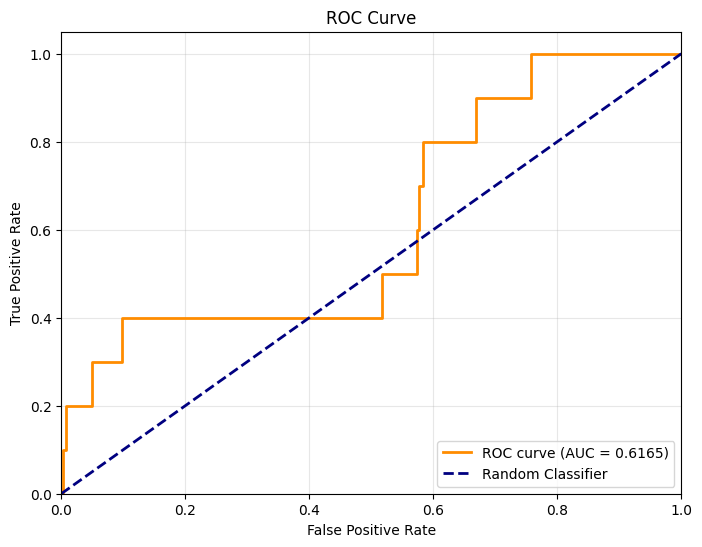

In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

if os.path.exists(LABEL_PATH):
    labels = pd.read_parquet(LABEL_PATH)
    
    label_col = None
    for c in ["label","is_alert","suspicious","y","target"]:
        if c in labels.columns:
            label_col = c
            break
    
    if label_col is not None:
        cust_col = get_customer_col(labels)
        eval_df = emb_df.merge(
            labels[[cust_col, label_col]].rename(columns={cust_col: "customer_id"}),
            on="customer_id",
            how="inner"
        )
        y = eval_df[label_col].astype(int)
        
        if y.nunique() >= 2:
            fpr, tpr, _ = roc_curve(y, eval_df["risk_score"])
            roc_auc = auc(fpr, tpr)
            
            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC Curve')
            plt.legend(loc="lower right")
            plt.grid(alpha=0.3)
            plt.show()
        else:
            print("Labels are single-class; ROC curve not available.")
else:
    print("No labels file found.")

In [ ]:
# -----------------------------
# Write/Update required model_output.csv (one row per customer_id)
# -----------------------------
OUT_PATH = "model_output.csv"

out = emb_df[["customer_id","predicted_label","risk_score"]].copy()
out["predicted_label"] = out["predicted_label"].astype(int)
out["risk_score"] = out["risk_score"].astype(float)

out.to_csv(OUT_PATH, index=False)
print("Wrote:", OUT_PATH, "| rows:", len(out))